# Task 2: Multi-class Perceptron
Introduction to Deep Learning — Assignment 0

## Setup

In [1]:
import sys
sys.path.append('../src')
import os
import numpy as np
import matplotlib.pyplot as plt
# paths and hyperparameters which is used throughout the notebook
DATA_DIR = "."
RESULTS_DIR = "../results/plots"
NUM_CLASSES = 10
NUM_EPOCHS = 20
DEFAULT_LR = 0.1
DEFAULT_INIT = "small_random"
DEFAULT_SEED = 0
NUM_RELIABILITY_RUNS = 10
os.makedirs(RESULTS_DIR, exist_ok=True)

## 1. Data loading

In [2]:
def load_data(data_dir=DATA_DIR):
   # loading the data from the given directory and return the first one that exist 
    def find(name_options):
        for name in name_options:
            path = os.path.join(data_dir, name)
            if os.path.exists(path):
                return path
        raise FileNotFoundError(
            f"None of {name_options} found in '{data_dir}'. "
            f"Files present: {os.listdir(data_dir) if os.path.isdir(data_dir) else 'DIR NOT FOUND'}")
    # locating each of the four required files and find the files if it is in the various names form.
    train_in_path = find(["train_in.csv", "train_in - Copy.csv", "train_in_-_Copy.csv"])
    train_out_path = find(["train_out.csv", "train_out - Copy.csv", "train_out_-_Copy.csv"])
    test_in_path = find(["test_in.csv", "test_in - Copy.csv", "test_in_-_Copy.csv"])
    test_out_path = find(["test_out.csv", "test_out - Copy.csv", "test_out_-_Copy.csv"])
    train_in = np.loadtxt(train_in_path, delimiter=",")
    test_in = np.loadtxt(test_in_path, delimiter=",")
    train_out = np.loadtxt(train_out_path, delimiter=",").astype(int)
    test_out = np.loadtxt(test_out_path, delimiter=",").astype(int)
    return train_in, train_out, test_in, test_out


def add_bias_column(X):
    ones = np.ones((X.shape[0], 1)) # 1 per sample to be multiplied by the bias weight
    return np.hstack([ones, X]) # stick the bias column in front of the real features

In [3]:
# load the four csv files into numpy arrays
train_in, train_out, test_in, test_out = load_data(DATA_DIR)
# argument inputs with a bias column so W can be a single matrix
T_train = add_bias_column(train_in)
T_test = add_bias_column(test_in)
# shapes should be (1707, 257) and (1000, 257)
print("Train inputs:", T_train.shape)
print("Test inputs: ", T_test.shape)

Train inputs: (1707, 257)
Test inputs:  (1000, 257)


## 2. perceptron core 

In [4]:
def init_weights(n_features, n_classes, strategy="small_random", seed=0):
    rng = np.random.default_rng(seed) # reproducible intialization
    if strategy == "zeros":
        return np.zeros((n_features, n_classes)) # No prior bias in any direction
    elif strategy == "small_random":
        return rng.normal(loc=0.0, scale=0.01, size=(n_features, n_classes)) #tiny random nudge
    elif strategy == "large_random":
        return rng.normal(loc=0.0, scale=1.0, size=(n_features, n_classes)) # much larger random start
    elif strategy == "uniform":
        return rng.uniform(-1.0, 1.0, size=(n_features, n_classes)) # uniform insead of Gaussian
    else:
        raise ValueError(f"Unknown init strategy: {strategy}")

def predict(T, W):
    scores = T @ W # matrix multiplication: one score per class per sample
    return np.argmax(scores, axis=1) # pick the class with the highest score per sample

def accuracy(T, y, W):
    preds = predict(T, W)
    return np.mean(preds == y) # fraction of predictions that mmatch the true label

def error_rate(T, y, W):
    preds = predict(T, W)
    return np.mean(preds != y) # complement of accuracy: fraction that are wrong

In [5]:
def train_one_epoch(T, y, W, lr):
    n_samples = T.shape[0]
    for i in range(n_samples): # loop over every training sample
        x = T[i] # this sample's augmented feature vector, shape (D+1,)
        true_label = y[i] # the correct digit for this sample
        scores = x @ W # score for each class under current weights
        pred_label = np.argmax(scores)  # the class the model currently predicts
        if pred_label != true_label: # reward the correct class where push its weight vector toward x
            W[:, true_label] += lr * x  # punish the predicted class and push its weight vector away from x
            W[:, pred_label] -= lr * x
    return W

def train(T_train, y_train, T_test, y_test, num_epochs=NUM_EPOCHS, lr=DEFAULT_LR, init="small_random", seed=DEFAULT_SEED, verbose=True):
    n_features = T_train.shape[1]
    W = init_weights(n_features, NUM_CLASSES, strategy=init, seed=seed)
 # store per epoch metrics so we can plot learning curves afterwards
    history = {"train_acc": [], "test_acc": [], "train_error_rate": [], "test_error_rate": []}
    for epoch in range(1, num_epochs + 1):
        W = train_one_epoch(T_train, y_train, W, lr) # one full sweep over the training data
       # evaluate the current weights on both train and test sets
        tr_acc = accuracy(T_train, y_train, W)
        te_acc = accuracy(T_test, y_test, W)
        tr_err = error_rate(T_train, y_train, W)
        te_err = error_rate(T_test, y_test, W)
      # log this epoch's numbers for later plotting
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        history["train_error_rate"].append(tr_err)
        history["test_error_rate"].append(te_err)
        if verbose:
            print(f"Epoch {epoch:2d}/{num_epochs} | "
                  f"train_acc={tr_acc:.4f}  test_acc={te_acc:.4f}  "
                  f"train_error_rate={tr_err:.4f}")
        # early stopping - perceptron theory guarantees convergence to 0 training
        # error on linearly separable data, so stop once that happens
        if tr_err == 0.0:
            if verbose:
                print(f"Converged (0 training error) at epoch {epoch}.")
            break

    return W, history

## 3. Training run

In [6]:
W, history = train(T_train, train_out, T_test, test_out, num_epochs=NUM_EPOCHS, lr=DEFAULT_LR, init=DEFAULT_INIT, seed=DEFAULT_SEED, verbose=True)

Epoch  1/20 | train_acc=0.8664  test_acc=0.7920  train_error_rate=0.1336
Epoch  2/20 | train_acc=0.9262  test_acc=0.8300  train_error_rate=0.0738
Epoch  3/20 | train_acc=0.9455  test_acc=0.8450  train_error_rate=0.0545
Epoch  4/20 | train_acc=0.9479  test_acc=0.8510  train_error_rate=0.0521
Epoch  5/20 | train_acc=0.9479  test_acc=0.8450  train_error_rate=0.0521
Epoch  6/20 | train_acc=0.9484  test_acc=0.8570  train_error_rate=0.0516
Epoch  7/20 | train_acc=0.9742  test_acc=0.8730  train_error_rate=0.0258
Epoch  8/20 | train_acc=0.9443  test_acc=0.8400  train_error_rate=0.0557
Epoch  9/20 | train_acc=0.9766  test_acc=0.8700  train_error_rate=0.0234
Epoch 10/20 | train_acc=0.9818  test_acc=0.8720  train_error_rate=0.0182
Epoch 11/20 | train_acc=0.9660  test_acc=0.8510  train_error_rate=0.0340
Epoch 12/20 | train_acc=0.9701  test_acc=0.8550  train_error_rate=0.0299
Epoch 13/20 | train_acc=0.9871  test_acc=0.8720  train_error_rate=0.0129
Epoch 14/20 | train_acc=0.9766  test_acc=0.8630  tr

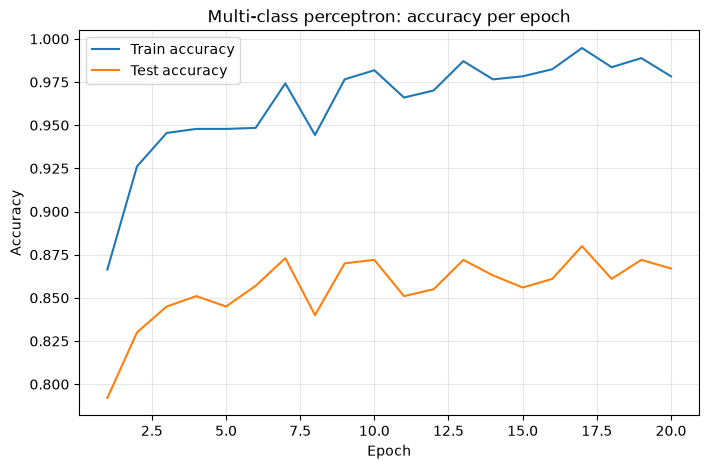

In [7]:
epochs = range(1, len(history["train_acc"]) + 1) # x-axis: epoch numbers, 1..N
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Train accuracy")
plt.plot(epochs, history["test_acc"], label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Multi-class perceptron: accuracy per epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/accuracy_curve.png", dpi=150, bbox_inches="tight") 
plt.show()

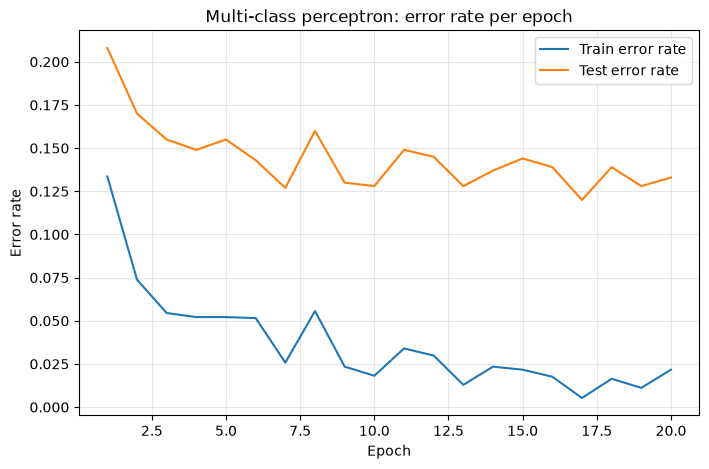

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_error_rate"], label="Train error rate")
plt.plot(epochs, history["test_error_rate"], label="Test error rate")
plt.xlabel("Epoch")
plt.ylabel("Error rate")
plt.title("Multi-class perceptron: error rate per epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/error_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Seed Reliability

In [9]:
def run_multiple_seeds(T_train, y_train, T_test, y_test, num_runs=NUM_RELIABILITY_RUNS, num_epochs=NUM_EPOCHS, lr=DEFAULT_LR, init="small_random"):
    final_accs = []
    for seed in range(num_runs): # retrain from scratch with each seed
        _, history = train(T_train, y_train, T_test, y_test, num_epochs=num_epochs, lr=lr, init=init, seed=seed, verbose=True)
        final_accs.append(history["test_acc"][-1]) # keep only the LAST epoch's test accuracy
    final_accs = np.array(final_accs)
     # summarize how much the final result varies run-to-run
    print(f"\nTest accuracy over {num_runs} seeds: "
          f"mean={final_accs.mean():.4f}, std={final_accs.std():.4f}")
    return final_accs
# run the reliability experiment with the default hyperparameters
seed_accuracies = run_multiple_seeds(T_train, train_out, T_test, test_out, num_runs=NUM_RELIABILITY_RUNS, num_epochs=NUM_EPOCHS, lr=DEFAULT_LR, init=DEFAULT_INIT)

Epoch  1/20 | train_acc=0.8664  test_acc=0.7920  train_error_rate=0.1336
Epoch  2/20 | train_acc=0.9262  test_acc=0.8300  train_error_rate=0.0738
Epoch  3/20 | train_acc=0.9455  test_acc=0.8450  train_error_rate=0.0545
Epoch  4/20 | train_acc=0.9479  test_acc=0.8510  train_error_rate=0.0521
Epoch  5/20 | train_acc=0.9479  test_acc=0.8450  train_error_rate=0.0521
Epoch  6/20 | train_acc=0.9484  test_acc=0.8570  train_error_rate=0.0516
Epoch  7/20 | train_acc=0.9742  test_acc=0.8730  train_error_rate=0.0258
Epoch  8/20 | train_acc=0.9443  test_acc=0.8400  train_error_rate=0.0557
Epoch  9/20 | train_acc=0.9766  test_acc=0.8700  train_error_rate=0.0234
Epoch 10/20 | train_acc=0.9818  test_acc=0.8720  train_error_rate=0.0182
Epoch 11/20 | train_acc=0.9660  test_acc=0.8510  train_error_rate=0.0340
Epoch 12/20 | train_acc=0.9701  test_acc=0.8550  train_error_rate=0.0299
Epoch 13/20 | train_acc=0.9871  test_acc=0.8720  train_error_rate=0.0129
Epoch 14/20 | train_acc=0.9766  test_acc=0.8630  tr

C:\RTemp\ipykernel_11936\1710459682.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(seed_accuracies, vert=True, tick_labels=["small_random init"])


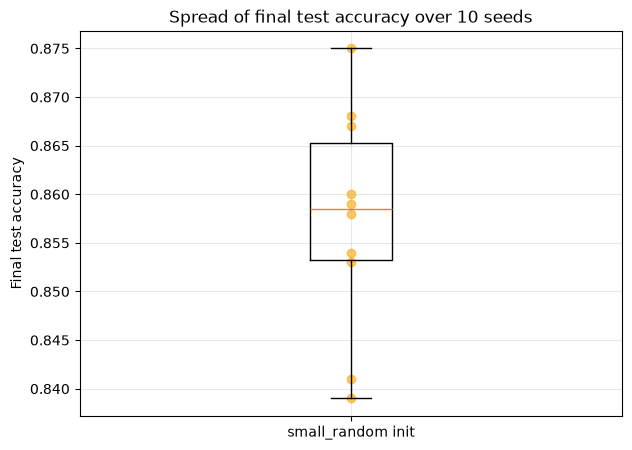

In [10]:
plt.figure(figsize=(7, 5)) # boxplot shows median/quartiles/whiskers of the final accuracies across seeds
plt.boxplot(seed_accuracies, vert=True, tick_labels=["small_random init"])
# overlay the individual data points so you can see each seed's result too
plt.scatter(np.ones_like(seed_accuracies), seed_accuracies, alpha=0.6, color="orange")
plt.ylabel("Final test accuracy")
plt.title(f"Spread of final test accuracy over {NUM_RELIABILITY_RUNS} seeds")
plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/seed_reliability.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Init  comparison

In [11]:
init_strategies = ["zeros", "small_random", "large_random"]
init_results = {}
for init in init_strategies:
    # same lr and seed for every strategy where it isolates the effect of init alone
    print(f"--- init={init} ---")
    _, hist = train(T_train, train_out, T_test, test_out, num_epochs=NUM_EPOCHS, lr=DEFAULT_LR, init=init, seed=DEFAULT_SEED, verbose=True)
    init_results[init] = hist
    print(f"init={init:>12} -> final test acc = {hist['test_acc'][-1]:.4f}\n")

--- init=zeros ---
Epoch  1/20 | train_acc=0.9063  test_acc=0.8350  train_error_rate=0.0937
Epoch  2/20 | train_acc=0.9127  test_acc=0.8170  train_error_rate=0.0873
Epoch  3/20 | train_acc=0.9607  test_acc=0.8610  train_error_rate=0.0393
Epoch  4/20 | train_acc=0.9361  test_acc=0.8460  train_error_rate=0.0639
Epoch  5/20 | train_acc=0.9537  test_acc=0.8590  train_error_rate=0.0463
Epoch  6/20 | train_acc=0.9666  test_acc=0.8680  train_error_rate=0.0334
Epoch  7/20 | train_acc=0.9707  test_acc=0.8670  train_error_rate=0.0293
Epoch  8/20 | train_acc=0.9725  test_acc=0.8720  train_error_rate=0.0275
Epoch  9/20 | train_acc=0.9854  test_acc=0.8770  train_error_rate=0.0146
Epoch 10/20 | train_acc=0.9871  test_acc=0.8690  train_error_rate=0.0129
Epoch 11/20 | train_acc=0.9631  test_acc=0.8470  train_error_rate=0.0369
Epoch 12/20 | train_acc=0.9912  test_acc=0.8710  train_error_rate=0.0088
Epoch 13/20 | train_acc=0.9666  test_acc=0.8540  train_error_rate=0.0334
Epoch 14/20 | train_acc=0.9795  

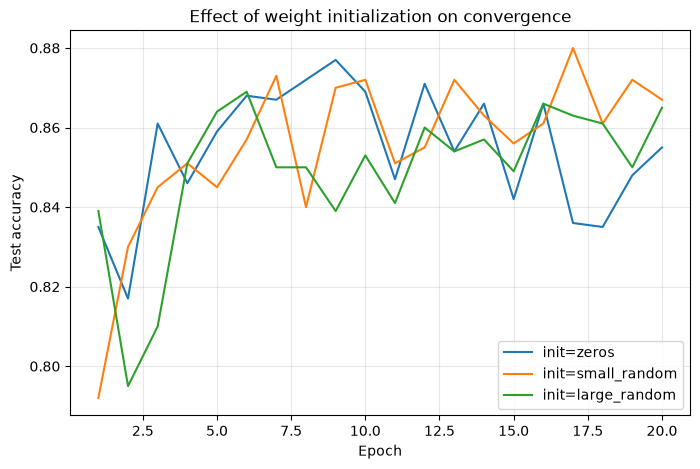

In [12]:
plt.figure(figsize=(8, 5))
for init, hist in init_results.items():
    ep = range(1, len(hist["test_acc"]) + 1)
    plt.plot(ep, hist["test_acc"], label=f"init={init}") # one curve per init strategy
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Effect of weight initialization on convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/init_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. learning rate

In [13]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
lr_results = {}
for lr in learning_rates:
    print(f"--- lr={lr} ---")
    # same init and seed for every lr where it isolates the effect of learning rate alone
    _, hist = train(T_train, train_out, T_test, test_out, num_epochs=NUM_EPOCHS, lr=lr, init=DEFAULT_INIT, seed=DEFAULT_SEED, verbose=True)
    lr_results[lr] = hist
    print(f"lr={lr:<8} -> final test acc = {hist['test_acc'][-1]:.4f}\n")

--- lr=0.001 ---
Epoch  1/20 | train_acc=0.9344  test_acc=0.8390  train_error_rate=0.0656
Epoch  2/20 | train_acc=0.9098  test_acc=0.7950  train_error_rate=0.0902
Epoch  3/20 | train_acc=0.9227  test_acc=0.8100  train_error_rate=0.0773
Epoch  4/20 | train_acc=0.9572  test_acc=0.8510  train_error_rate=0.0428
Epoch  5/20 | train_acc=0.9695  test_acc=0.8640  train_error_rate=0.0305
Epoch  6/20 | train_acc=0.9713  test_acc=0.8690  train_error_rate=0.0287
Epoch  7/20 | train_acc=0.9631  test_acc=0.8500  train_error_rate=0.0369
Epoch  8/20 | train_acc=0.9613  test_acc=0.8500  train_error_rate=0.0387
Epoch  9/20 | train_acc=0.9367  test_acc=0.8390  train_error_rate=0.0633
Epoch 10/20 | train_acc=0.9783  test_acc=0.8530  train_error_rate=0.0217
Epoch 11/20 | train_acc=0.9549  test_acc=0.8410  train_error_rate=0.0451
Epoch 12/20 | train_acc=0.9783  test_acc=0.8600  train_error_rate=0.0217
Epoch 13/20 | train_acc=0.9795  test_acc=0.8540  train_error_rate=0.0205
Epoch 14/20 | train_acc=0.9713  te

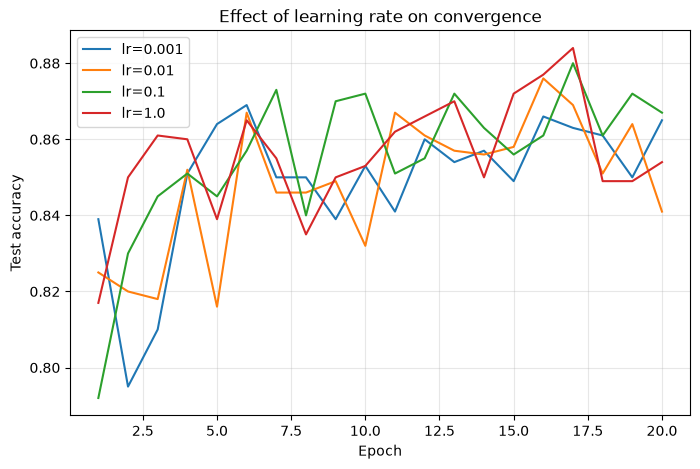

In [14]:
plt.figure(figsize=(8, 5))
for lr, hist in lr_results.items():
    ep = range(1, len(hist["test_acc"]) + 1)
    plt.plot(ep, hist["test_acc"], label=f"lr={lr}") # one curve per learning rate
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Effect of learning rate on convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{RESULTS_DIR}/lr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()